In [1]:
import numpy as np

In [2]:
matrix = [[1,4], [-2, 1], [4,2]]
A = np.array(matrix)

vector = [4, 2, 1]
y = np.array(vector)

In [3]:
A_t = A.transpose()

In [4]:
A_t @ A 

array([[21, 10],
       [10, 21]])

In [5]:
A_t @ y

array([ 4, 20])

In [6]:
# the normal equation come from the system A_t @ A x = A_t @ y
# x = ( A_t @ A )⁻¹ A_t @ y

In [7]:
import numpy.linalg as alg


In [9]:
x = alg.inv(A_t @ A) @ (A_t @ y)
print(x)

[-0.34017595  1.1143695 ]


In [8]:
import matplotlib.pyplot as plt

In [13]:
print(A)

[[ 1  4]
 [-2  1]
 [ 4  2]]


In [43]:
a = np.linspace(1, 5, 3)
#print(a)
b = np.linspace(0, 1, 6)
#print(b)
A, B = np.meshgrid(a,b)
print(A, B, A+B, sep='\n')
print(A[1], B[1], (A+B)[1])

[[1. 3. 5.]
 [1. 3. 5.]
 [1. 3. 5.]
 [1. 3. 5.]
 [1. 3. 5.]
 [1. 3. 5.]]
[[0.  0.  0. ]
 [0.2 0.2 0.2]
 [0.4 0.4 0.4]
 [0.6 0.6 0.6]
 [0.8 0.8 0.8]
 [1.  1.  1. ]]
[[1.  3.  5. ]
 [1.2 3.2 5.2]
 [1.4 3.4 5.4]
 [1.6 3.6 5.6]
 [1.8 3.8 5.8]
 [2.  4.  6. ]]
[1. 3. 5.] [0.2 0.2 0.2] [1.2 3.2 5.2]


In [10]:
import matplotlib.pyplot as plt

In [12]:
print(A, A[:, 0], sep='\n')

[[ 1  4]
 [-2  1]
 [ 4  2]]
[ 1 -2  4]


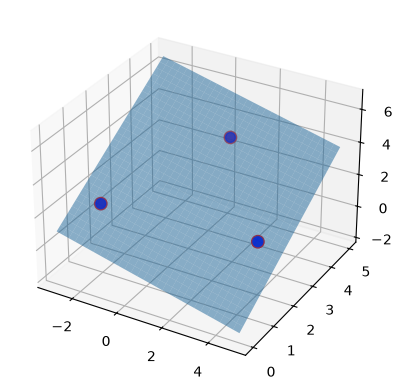

In [13]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(A[:, 0], A[:, 1], y, color='red', s=80)
ax.scatter(A[:, 0], A[:, 1], y, color='blue', s=50)
x1_plane = np.linspace(-3, 5, 30)
x2_plane = np.linspace(0, 5, 30)
X1, X2 = np.meshgrid(x1_plane, x2_plane)
Y = X1 * x[0] + X2 * x[1]
ax.plot_surface(X1, X2, Y, alpha=0.5)

In [50]:
print(A@x)
print(y)
print(alg.norm(y-A@x,2), alg.norm(A@x - y, 2), y-A@x, A@x-y, sep='\n')

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

In [15]:
# x = ( A_t @ A )⁻¹ A_t @ y
X = np.array([[2,4], [3,6], [1,2]])
y = np.array([3, 2, 0])
Theta = alg.pinv(X.T @  X) @ (X.T @ y)
print(Theta)

[0.17142857 0.34285714]


In [16]:
min_x0 = min(X[:, 0]) -1
min_x1 = min(X[:, 1]) -1
max_x0 = max(X[:, 0]) + 1
max_x1 = max(X[:, 1]) + 1

In [46]:
x0_plane = np.linspace(min_x0, max_x0, 30)
x1_plane = np.linspace(min_x1, max_x1, 30)
X0, X1 = np.meshgrid(x0_plane, x1_plane)
y_model = Theta[0] * X0 + Theta[1] * X1

print(X0[0], Theta[0], X1[0], Theta[1], y_model[0], sep='\n')
y_model[0,1] == X0[0,1] * Theta[0] + X1[0,1] * Theta[1] 

[0.         0.13793103 0.27586207 0.4137931  0.55172414 0.68965517
 0.82758621 0.96551724 1.10344828 1.24137931 1.37931034 1.51724138
 1.65517241 1.79310345 1.93103448 2.06896552 2.20689655 2.34482759
 2.48275862 2.62068966 2.75862069 2.89655172 3.03448276 3.17241379
 3.31034483 3.44827586 3.5862069  3.72413793 3.86206897 4.        ]
0.1714285714285715
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
0.3428571428571429
[0.34285714 0.36650246 0.39014778 0.4137931  0.43743842 0.46108374
 0.48472906 0.50837438 0.5320197  0.55566502 0.57931034 0.60295567
 0.62660099 0.65024631 0.67389163 0.69753695 0.72118227 0.74482759
 0.76847291 0.79211823 0.81576355 0.83940887 0.86305419 0.88669951
 0.91034483 0.93399015 0.95763547 0.98128079 1.00492611 1.02857143]


np.True_

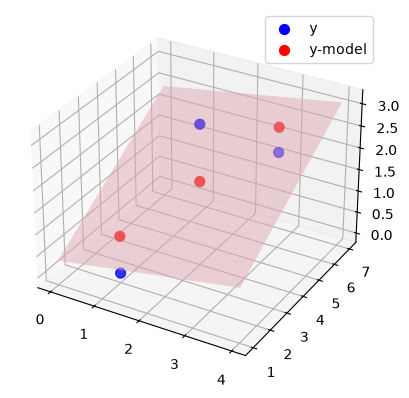

In [31]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:,0], X[:, 1], y, label='y', color='blue', s=50)
ax.scatter(X[:, 0], X[:, 1], X@Theta, label='y-model', color='red', s=50)
ax.plot_surface(X0, X1, y_model, alpha=0.5, color='pink')

ax.legend()

In [51]:
print(X@Theta, y, y - X@Theta)
print(alg.norm(y-X@Theta, 2), alg.norm(X@Theta - y))

[1.71428571 2.57142857 0.85714286] [3 2 0] [ 1.28571429 -0.57142857 -0.85714286]
1.647508942095828 1.647508942095828
